In [14]:
import pickle as pkl
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.corpus import brown
from nltk import download
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import random
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import json

torch.manual_seed(42)

In [15]:
import importlib
import enc_dec_lstm
importlib.reload(enc_dec_lstm)
from enc_dec_lstm import Encoder, Decoder, Encoder_Decoder_Model

In [16]:
if torch.cuda.is_available():
	device = torch.device("cuda")
elif torch.xpu.is_available():
	device = torch.device("xpu")
else:
	device = torch.device("cpu")
device

device(type='cuda')

In [ ]:
with open('../data/test_data.pkl', 'rb') as f:
    test_data = pkl.load(f)

In [18]:
with open('tokenizer/word2idx.json', 'r') as f:
    word2idx = json.load(f)
    idx2word = {v: k for k, v in word2idx.items()}
with open('tokenizer/tag2idx.json', 'r') as f:
    tag2idx = json.load(f)
    idx2tag = {v: k for k, v in tag2idx.items()}
with open("tokenizer/word_embeddings.pt", "rb") as f:
    train_embeddings = torch.load(f)

In [19]:
vocab_size = len(word2idx)
tag_size = len(tag2idx)

In [20]:
class POSTagDataset(Dataset):
    def __init__(self, sentences):
        self.data = []
        for sent in sentences:
            words, tags = zip(*sent)
            
            word_ids = [word2idx.get(w, 1) for w in words]
            tag_ids = [tag2idx.get(t, 0) if t in tag2idx else 0 for t in tags]

            length = len(word_ids)

            self.data.append((torch.tensor(word_ids).to(device), torch.tensor(tag_ids).to(device), length))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

In [21]:
test_dataset = POSTagDataset(test_data)

In [81]:
batch_size=128
test_loader = DataLoader(test_dataset, batch_size=1)

In [82]:
epochs = 20
embed_dim = 300
hidden_dim = 256
model=Encoder_Decoder_Model(vocab_size, embed_dim, hidden_dim, tag_size, tag2idx["<SOS>"], train_embeddings).to(device)
lr=0.001
model.load_state_dict(torch.load(f'models/encoder_decoder_model_{lr}lr_{batch_size}bs_{epochs}epochs.pth', map_location=device))

<All keys matched successfully>

In [83]:
preds=[]
actuals=[]

In [84]:
count=-100

In [85]:
model.eval()
with torch.no_grad():
    for test_batch in tqdm(test_loader, desc="Testing", total=len(test_loader)):
        words_batch, tags_batch, length_batch = test_batch
        input_seq = words_batch
        output_tags = model.generate_beam_search(input_seq, words_batch.shape[1], length_batch)
        tags=[[idx2tag[idx.item()] for idx in output_tags[i]] for i in range(len(output_tags))]
        preds+=tags[0][1:]
        actuals+=[idx2tag[idx.item()] for idx in tags_batch[0]]
        if count==0:
            break
        count-=1

Testing: 100%|██████████| 5734/5734 [08:49<00:00, 10.84it/s]


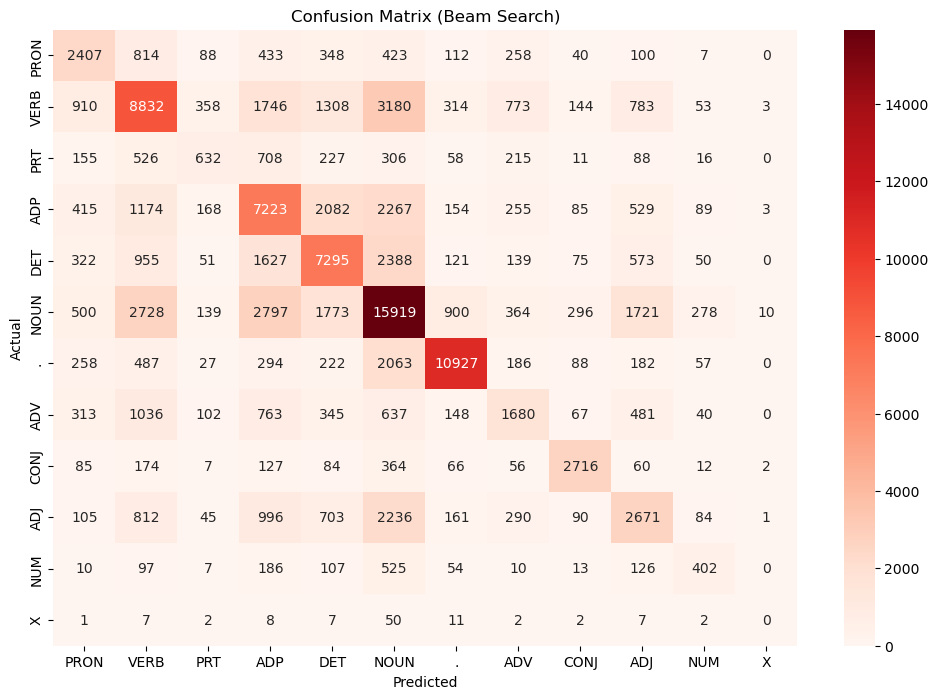

In [86]:
confusion_matrix_data = confusion_matrix(actuals, preds, labels=list(tag2idx.keys())[:-2])
plt.figure(figsize=(12, 8))
sns.heatmap(
    confusion_matrix_data,
    annot=True,
    cmap="Reds",
    fmt="d",
    xticklabels=list(tag2idx.keys())[:-2],
    yticklabels=list(tag2idx.keys())[:-2],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Beam Search)")
plt.savefig("confusion_matrix_beam.png", dpi=300, bbox_inches="tight")

In [87]:
print(classification_report(
    actuals, preds, labels=list(tag2idx.keys())[:-2], digits=4
))

              precision    recall  f1-score   support

        PRON     0.4392    0.4785    0.4580      5030
        VERB     0.5006    0.4799    0.4900     18404
         PRT     0.3887    0.2148    0.2767      2942
         ADP     0.4272    0.5001    0.4608     14444
         DET     0.5031    0.5366    0.5193     13596
        NOUN     0.5244    0.5805    0.5510     27425
           .     0.8389    0.7388    0.7856     14791
         ADV     0.3974    0.2994    0.3415      5612
        CONJ     0.7488    0.7237    0.7360      3753
         ADJ     0.3648    0.3260    0.3443      8194
         NUM     0.3688    0.2615    0.3061      1537
           X     0.0000    0.0000    0.0000        99

    accuracy                         0.5241    115827
   macro avg     0.4585    0.4283    0.4391    115827
weighted avg     0.5263    0.5241    0.5228    115827



In [88]:
preds=[]
actuals=[]

In [89]:
count=-100

In [90]:
model.eval()
with torch.no_grad():
    for test_batch in tqdm(test_loader, desc="Testing", total=len(test_loader)):
        words_batch, tags_batch, length_batch = test_batch
        input_seq = words_batch
        output_tags = model.generate(input_seq, words_batch.shape[1], length_batch)
        tags=[[idx2tag[idx.item()] for idx in output_tags[i]] for i in range(len(output_tags))]
        preds+=tags[0][1:]
        actuals+=[idx2tag[idx.item()] for idx in tags_batch[0]]
        if count==0:
            break
        count-=1

Testing: 100%|██████████| 5734/5734 [02:25<00:00, 39.47it/s]


In [91]:
len(preds), len(actuals)

(115827, 115827)

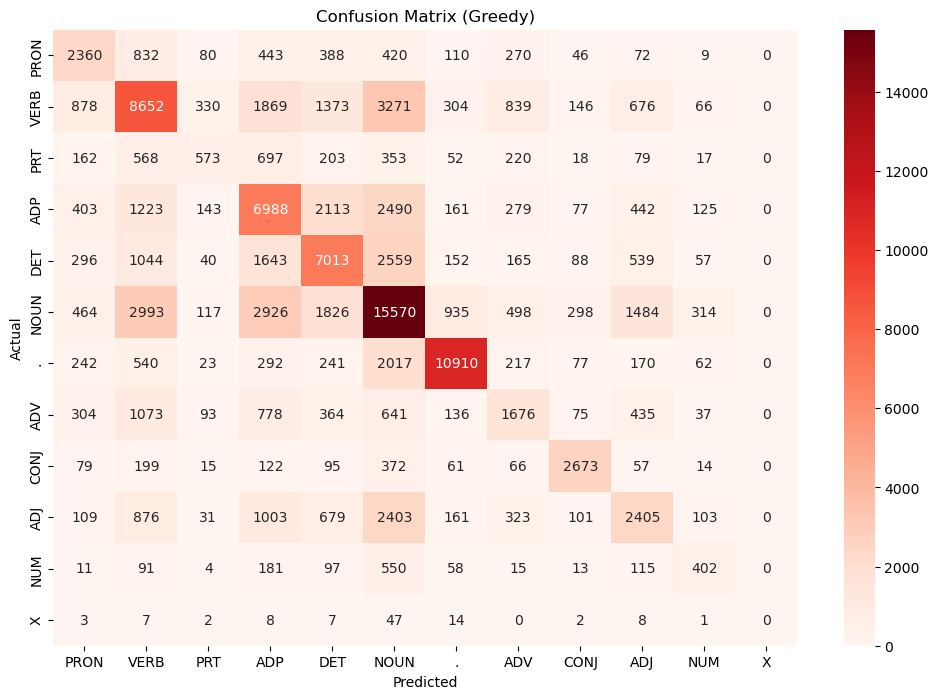

In [92]:
confusion_matrix_data = confusion_matrix(actuals, preds, labels=list(tag2idx.keys())[:-2])
plt.figure(figsize=(12, 8))
sns.heatmap(
    confusion_matrix_data,
    annot=True,
    cmap="Reds",
    fmt="d",
    xticklabels=list(tag2idx.keys())[:-2],
    yticklabels=list(tag2idx.keys())[:-2],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Greedy)")
plt.savefig("confusion_matrix_greedy.png", dpi=300, bbox_inches="tight")

In [ ]:
print(classification_report(
    actuals, preds, labels=list(tag2idx.keys())[:-2], digits=4
))

/scratch/deeptanshumalu/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/scratch/deeptanshumalu/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        PRON     0.4444    0.4692    0.4564      5030
        VERB     0.4781    0.4701    0.4741     18404
         PRT     0.3949    0.1948    0.2609      2942
         ADP     0.4123    0.4838    0.4452     14444
         DET     0.4870    0.5158    0.5010     13596
        NOUN     0.5073    0.5677    0.5358     27425
           .     0.8358    0.7376    0.7836     14791
         ADV     0.3669    0.2986    0.3293      5612
        CONJ     0.7396    0.7122    0.7257      3753
         ADJ     0.3710    0.2935    0.3277      8194
         NUM     0.3331    0.2615    0.2930      1537
           X     0.0000    0.0000    0.0000        99

    accuracy                         0.5113    115827
   macro avg     0.4475    0.4171    0.4277    115827
weighted avg     0.5131    0.5113    0.5096    115827



/scratch/deeptanshumalu/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


: 

In [ ]:
import os
os._exit(0)

: 